In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid")
%matplotlib inline

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [4]:
# Load all datasets
steps = pd.read_csv('../data/steps.csv')
heart_rate = pd.read_csv('../data/heart_rate.csv')
sleep = pd.read_csv('../data/sleep.csv')
calories = pd.read_csv('../data/active_calories.csv')
distance = pd.read_csv('../data/distance.csv')
workouts = pd.read_csv('../data/workouts.csv')

for df in [steps, heart_rate, sleep, calories, distance, workouts]:
    df['start'] = pd.to_datetime(df['start'])
    df['end'] = pd.to_datetime(df['end'])

print("✅ All data loaded!")
print(f"\n📊 Dataset shapes:")
print(f"  Steps:           {steps.shape}")
print(f"  Heart Rate:      {heart_rate.shape}")
print(f"  Sleep:           {sleep.shape}")
print(f"  Calories:        {calories.shape}")
print(f"  Distance:        {distance.shape}")
print(f"  Workouts:        {workouts.shape}")
    

✅ All data loaded!

📊 Dataset shapes:
  Steps:           (452738, 5)
  Heart Rate:      (149562, 5)
  Sleep:           (16561, 5)
  Calories:        (372918, 5)
  Distance:        (160438, 5)
  Workouts:        (111, 6)


In [5]:
# Quick peek at each dataset
datasets = {
    'Steps': steps,
    'Heart Rate': heart_rate,
    'Sleep': sleep,
    'Calories': calories,
    'Distance': distance,
    'Workouts': workouts
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"📋 {name}")
    print(f"{'='*50}")
    print(f"Date range: {df['start'].min().date()} → {df['start'].max().date()}")
    print(f"Shape: {df.shape}")
    print(f"Missing values:\n{df.isnull().sum()}")
    print(f"\nSample:")
    display(df.head(3))


📋 Steps
Date range: 2017-04-09 → 2026-03-05
Shape: (452738, 5)
Missing values:
start     0
end       0
value     0
unit      0
source    0
dtype: int64

Sample:


,start,end,value,unit,source
0,2017-04-09 20:15:54-06:00,2017-04-09 20:25:16-06:00,18,count,🍀😺
1,2017-04-09 20:32:49-06:00,2017-04-09 20:40:16-06:00,31,count,🍀😺
2,2017-04-09 22:10:47-06:00,2017-04-09 22:17:05-06:00,17,count,🍀😺



📋 Heart Rate
Date range: 2020-06-05 → 2025-07-11
Shape: (149562, 5)
Missing values:
start     0
end       0
value     0
unit      0
source    0
dtype: int64

Sample:


,start,end,value,unit,source
0,2020-06-05 10:40:43-06:00,2020-06-05 10:40:43-06:00,75.00,count/min,念禹含’s Apple Watch
1,2020-06-05 10:43:28-06:00,2020-06-05 10:43:28-06:00,70.00,count/min,念禹含’s Apple Watch
2,2020-06-05 10:48:52-06:00,2020-06-05 10:48:52-06:00,69.00,count/min,念禹含’s Apple Watch



📋 Sleep
Date range: 2017-07-08 → 2025-01-13
Shape: (16561, 5)
Missing values:
start         0
end           0
value     16561
unit      16561
source        0
dtype: int64

Sample:


...

,start,end,value,unit,source
0,2020-03-23 10:00:00-06:00,2020-03-23 10:00:00-06:00,198.19,Cal,薄荷健康
1,2020-03-24 10:00:00-06:00,2020-03-24 10:00:00-06:00,197.80,Cal,薄荷健康
2,2020-03-25 10:00:00-06:00,2020-03-25 10:00:00-06:00,197.02,Cal,薄荷健康



📋 Distance
Date range: 2017-04-09 → 2026-03-05
Shape: (160438, 5)
Missing values:
start     0
end       0
value     0
unit      0
source    0
dtype: int64

Sample:


,start,end,value,unit,source
0,2017-04-09 20:15:54-06:00,2017-04-09 20:25:16-06:00,0.01,km,🍀😺
1,2017-04-09 20:32:49-06:00,2017-04-09 20:40:16-06:00,0.02,km,🍀😺
2,2017-04-09 22:10:47-06:00,2017-04-09 22:17:05-06:00,0.01,km,🍀😺



📋 Workouts
Date range: 2020-06-11 → 2025-07-06
Shape: (111, 6)
Missing values:
activity          0
start             0
end               0
duration_min      0
calories        111
distance        111
dtype: int64

Sample:


,activity,start,end,duration_min,calories,distance
0,Walking,2020-06-11 04:18:01-06:00,2020-06-11 04:36:49-06:00,18.79,NaN,NaN
1,Cycling,2020-07-02 04:39:29-06:00,2020-07-02 09:16:26-06:00,0.04,NaN,NaN
2,Walking,2020-10-08 20:35:11-06:00,2020-10-09 03:24:47-06:00,245.73,NaN,NaN


In [7]:
# steps: daily total

steps['date']= steps['start'].dt.date
daily_steps = steps.groupby('date')['value'].sum().reset_index()
daily_steps.columns = ['date','steps']

# distance: daily total
distance['date'] = distance['start'].dt.date
daily_distance = distance.groupby('date')['value'].sum().reset_index()
daily_distance.columns = ['date', 'distance_km']

# calories: daily total 
calories['date'] = calories['start'].dt.date
daily_calories = calories.groupby('date')['value'].sum().reset_index()
daily_calories.columns = ['date', 'calories']

# heart_rate daily average, min, max
heart_rate['date'] = heart_rate['start'].dt.date
daily_hr = heart_rate.groupby('date')['value'].agg(
    hr_avg='mean',
    hr_min='min',
    hr_max='max'
).reset_index()

# sleep: calculate duration from start/end 
sleep['date'] = sleep['start'].dt.date
sleep['duration_hrs'] = (sleep['end'] - sleep['start']).dt.total_seconds() / 3600
daily_sleep = sleep.groupby('date')['duration_hrs'].sum().reset_index()
daily_sleep.columns = ['date', 'sleep_hrs']

print("✅ Daily aggregations done!")
print(f"  Daily steps:    {len(daily_steps):,} days")
print(f"  Daily distance: {len(daily_distance):,} days")
print(f"  Daily calories: {len(daily_calories):,} days")
print(f"  Daily HR:       {len(daily_hr):,} days")
print(f"  Daily sleep:    {len(daily_sleep):,} days")



✅ Daily aggregations done!
  Daily steps:    3,126 days
  Daily distance: 3,111 days
  Daily calories: 686 days
  Daily HR:       623 days
  Daily sleep:    1,556 days


In [8]:
from functools import reduce

# Convert all date columns to same type
for df in [daily_steps, daily_distance, daily_calories, daily_hr, daily_sleep]:
    df['date'] = pd.to_datetime(df['date'])

# Merge all on date
dfs = [daily_steps, daily_distance, daily_calories, daily_hr, daily_sleep]
master = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)

# Sort by date
master = master.sort_values('date').reset_index(drop=True)

# Add useful time columns
master['year']      = master['date'].dt.year
master['month']     = master['date'].dt.month
master['weekday']   = master['date'].dt.day_name()
master['week']      = master['date'].dt.isocalendar().week.astype(int)

print(f"✅ Master dataframe created!")
print(f"   Shape: {master.shape}")
print(f"   Date range: {master['date'].min().date()} → {master['date'].max().date()}")
print(f"\n📊 Missing values per column:")
print(master.isnull().sum())
print(f"\nSample:")
display(master.head())

✅ Master dataframe created!
   Shape: (3126, 12)
   Date range: 2017-04-09 → 2026-03-05

📊 Missing values per column:
date              0
steps             0
distance_km      15
calories       2440
hr_avg         2503
hr_min         2503
hr_max         2503
sleep_hrs      1570
year              0
month             0
weekday           0
week              0
dtype: int64

Sample:


,date,steps,distance_km,calories,hr_avg,hr_min,hr_max,sleep_hrs,year,month,weekday,week
0,2017-04-09,448,0.32,NaN,NaN,NaN,NaN,NaN,2017,4,Sunday,14
1,2017-04-10,3078,2.20,NaN,NaN,NaN,NaN,NaN,2017,4,Monday,15
2,2017-04-11,12809,8.78,NaN,NaN,NaN,NaN,NaN,2017,4,Tuesday,15
3,2017-04-12,9604,6.40,NaN,NaN,NaN,NaN,NaN,2017,4,Wednesday,15
4,2017-04-13,5204,3.23,NaN,NaN,NaN,NaN,NaN,2017,4,Thursday,15


In [9]:
# Save master to CSV for later use
master.to_csv('../data/master_daily.csv', index=False)
print("✅ Saved master_daily.csv")

# Summary statistics
print("\n📊 Summary Statistics:")
display(master[['steps', 'distance_km', 'calories', 'hr_avg', 'sleep_hrs']].describe().round(2))

# Quick health benchmarks
print("\n🎯 Personal Health Benchmarks:")
print(f"  Avg daily steps:     {master['steps'].mean():,.0f}  (goal: 10,000)")
print(f"  % days hit 10k steps: {(master['steps'] >= 10000).mean()*100:.1f}%")
print(f"  Avg sleep:           {master['sleep_hrs'].mean():.1f} hrs  (goal: 8hrs)")
print(f"  % days good sleep:   {(master['sleep_hrs'] >= 7).mean()*100:.1f}%")
print(f"  Avg resting HR:      {master['hr_avg'].mean():.1f} bpm  (healthy: 60-100)")

✅ Saved master_daily.csv

📊 Summary Statistics:


,steps,distance_km,calories,hr_avg,sleep_hrs
count,3126.00,3111.00,686.00,623.00,1556.00
mean,6666.80,4.45,271.91,85.96,7.85
std,5403.02,3.71,167.68,11.81,4.92
min,1.00,0.00,0.01,50.77,0.00
25%,2874.50,1.84,160.46,78.40,5.36
50%,5663.50,3.70,273.16,84.96,6.82
75%,8798.75,5.89,364.25,93.03,8.47
max,38761.00,26.49,922.19,142.80,33.18



🎯 Personal Health Benchmarks:
  Avg daily steps:     6,667  (goal: 10,000)
  % days hit 10k steps: 19.5%
  Avg sleep:           7.9 hrs  (goal: 8hrs)
  % days good sleep:   23.3%
  Avg resting HR:      86.0 bpm  (healthy: 60-100)


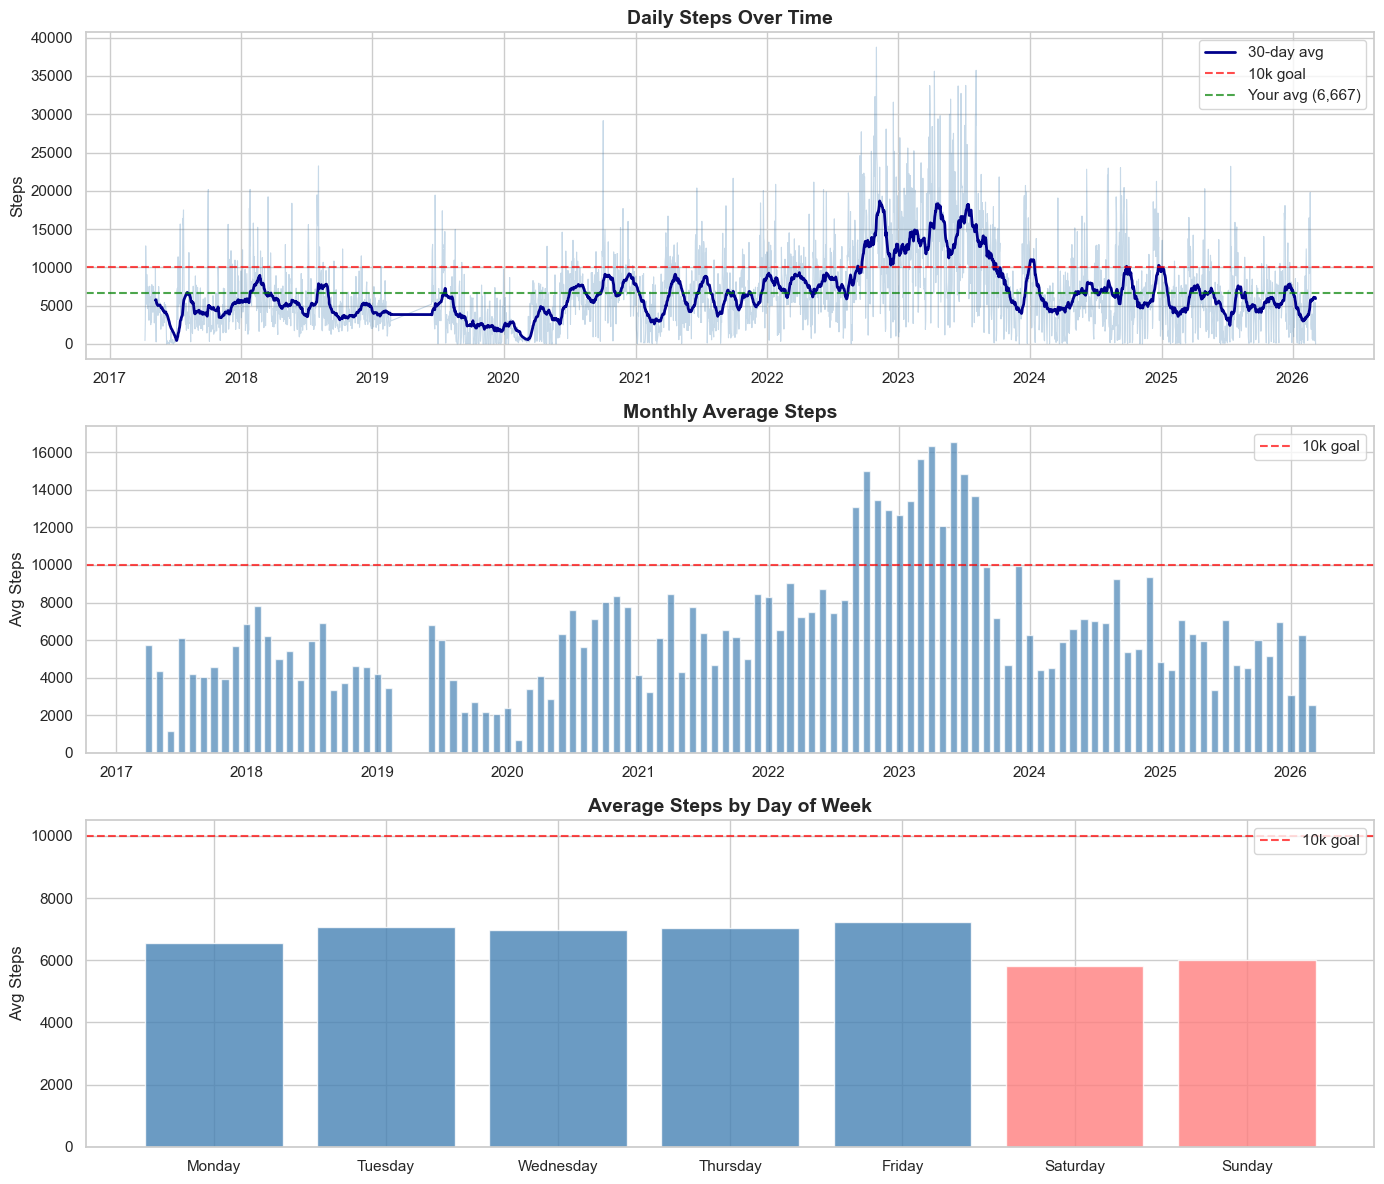

✅ Saved steps_analysis.png


In [10]:
# visualization 

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── Plot 1: Daily steps over time ──────────────────
axes[0].plot(master['date'], master['steps'], alpha=0.3, color='steelblue', linewidth=0.8)
# 30-day rolling average
master['steps_30d'] = master['steps'].rolling(30).mean()
axes[0].plot(master['date'], master['steps_30d'], color='darkblue', linewidth=2, label='30-day avg')
axes[0].axhline(10000, color='red', linestyle='--', alpha=0.7, label='10k goal')
axes[0].axhline(master['steps'].mean(), color='green', linestyle='--', alpha=0.7, label=f'Your avg ({master["steps"].mean():,.0f})')
axes[0].set_title('Daily Steps Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Steps')
axes[0].legend()

# ── Plot 2: Monthly average steps ──────────────────
monthly_steps = master.groupby(['year', 'month'])['steps'].mean().reset_index()
monthly_steps['date'] = pd.to_datetime(monthly_steps[['year', 'month']].assign(day=1))
axes[1].bar(monthly_steps['date'], monthly_steps['steps'], 
            color='steelblue', alpha=0.7, width=20)
axes[1].axhline(10000, color='red', linestyle='--', alpha=0.7, label='10k goal')
axes[1].set_title('Monthly Average Steps', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Steps')
axes[1].legend()

# ── Plot 3: Steps by day of week ───────────────────
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_steps = master.groupby('weekday')['steps'].mean().reindex(dow_order)
colors = ['#ff7f7f' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in dow_order]
axes[2].bar(dow_steps.index, dow_steps.values, color=colors, alpha=0.8)
axes[2].axhline(10000, color='red', linestyle='--', alpha=0.7, label='10k goal')
axes[2].set_title('Average Steps by Day of Week', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Avg Steps')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/steps_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved steps_analysis.png")


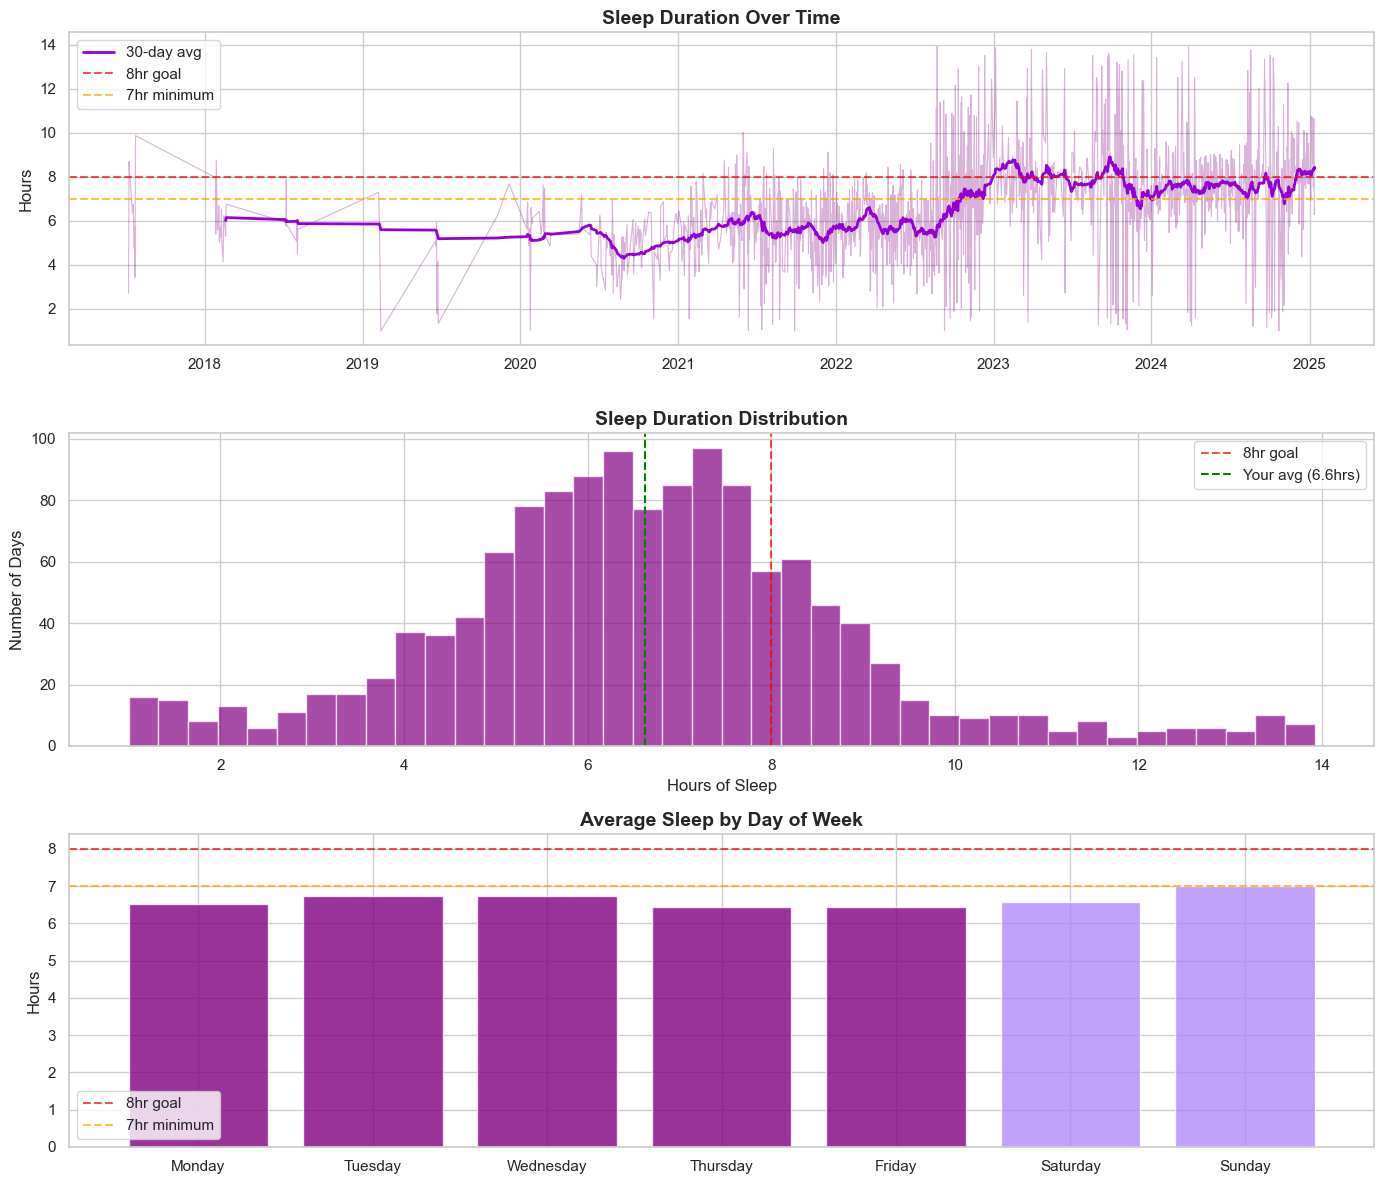

✅ Saved sleep_analysis.png


In [11]:
# sleep analysis 

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Filter out unrealistic sleep values (>14 hrs likely double-counted naps)
sleep_clean = master[master['sleep_hrs'].between(1, 14)].copy()

# ── Plot 1: Sleep duration over time ───────────────
axes[0].plot(sleep_clean['date'], sleep_clean['sleep_hrs'], 
             alpha=0.3, color='purple', linewidth=0.8)
sleep_clean['sleep_30d'] = sleep_clean['sleep_hrs'].rolling(30).mean()
axes[0].plot(sleep_clean['date'], sleep_clean['sleep_30d'], 
             color='darkviolet', linewidth=2, label='30-day avg')
axes[0].axhline(8, color='red', linestyle='--', alpha=0.7, label='8hr goal')
axes[0].axhline(7, color='orange', linestyle='--', alpha=0.7, label='7hr minimum')
axes[0].set_title('Sleep Duration Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Hours')
axes[0].legend()

# ── Plot 2: Sleep distribution ─────────────────────
axes[1].hist(sleep_clean['sleep_hrs'], bins=40, color='purple', alpha=0.7, edgecolor='white')
axes[1].axvline(8, color='red', linestyle='--', alpha=0.7, label='8hr goal')
axes[1].axvline(sleep_clean['sleep_hrs'].mean(), color='green', linestyle='--', 
                label=f'Your avg ({sleep_clean["sleep_hrs"].mean():.1f}hrs)')
axes[1].set_title('Sleep Duration Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hours of Sleep')
axes[1].set_ylabel('Number of Days')
axes[1].legend()

# ── Plot 3: Sleep by day of week ───────────────────
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sleep = sleep_clean.groupby('weekday')['sleep_hrs'].mean().reindex(dow_order)
colors = ['#b088f9' if d in ['Saturday', 'Sunday'] else 'purple' for d in dow_order]
axes[2].bar(dow_sleep.index, dow_sleep.values, color=colors, alpha=0.8)
axes[2].axhline(8, color='red', linestyle='--', alpha=0.7, label='8hr goal')
axes[2].axhline(7, color='orange', linestyle='--', alpha=0.7, label='7hr minimum')
axes[2].set_title('Average Sleep by Day of Week', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Hours')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/sleep_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved sleep_analysis.png")

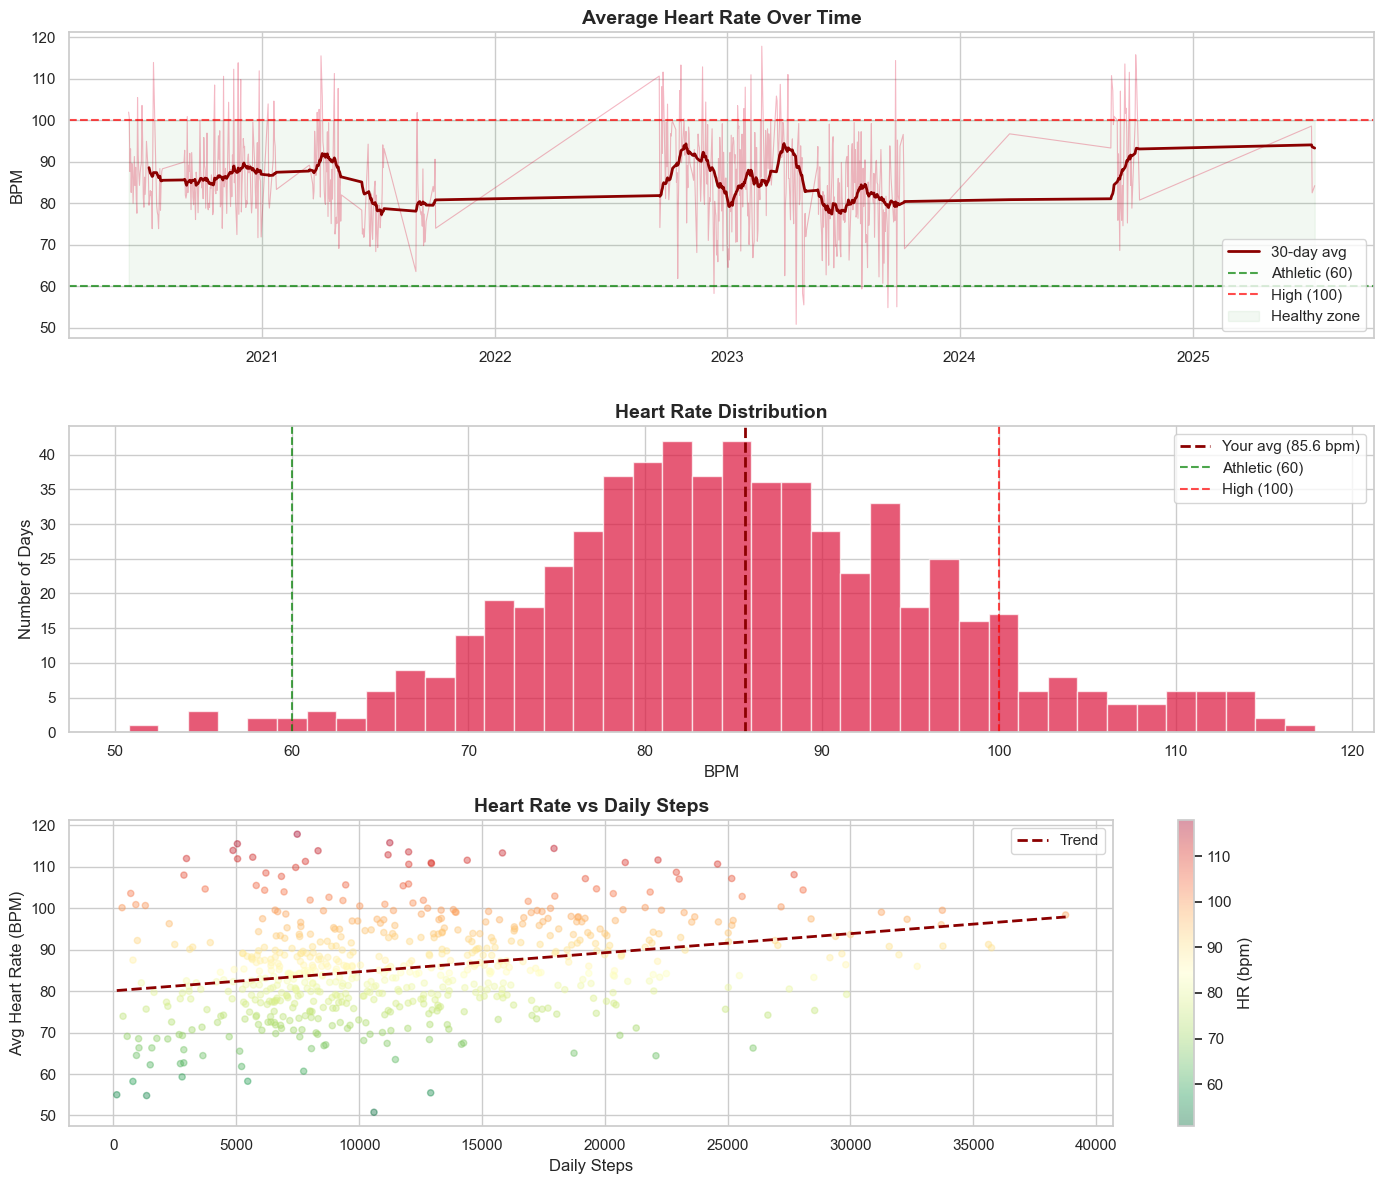

✅ Saved heart_rate_analysis.png


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Filter realistic heart rate values
hr_clean = master[master['hr_avg'].between(40, 120)].copy()

# ── Plot 1: Heart rate over time ───────────────────
axes[0].plot(hr_clean['date'], hr_clean['hr_avg'],
             alpha=0.3, color='crimson', linewidth=0.8)
hr_clean['hr_30d'] = hr_clean['hr_avg'].rolling(30).mean()
axes[0].plot(hr_clean['date'], hr_clean['hr_30d'],
             color='darkred', linewidth=2, label='30-day avg')
axes[0].axhline(60, color='green', linestyle='--', alpha=0.7, label='Athletic (60)')
axes[0].axhline(100, color='red', linestyle='--', alpha=0.7, label='High (100)')
axes[0].fill_between(hr_clean['date'], 60, 100, alpha=0.05, color='green', label='Healthy zone')
axes[0].set_title('Average Heart Rate Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('BPM')
axes[0].legend()

# ── Plot 2: HR distribution ────────────────────────
axes[1].hist(hr_clean['hr_avg'], bins=40, color='crimson', alpha=0.7, edgecolor='white')
axes[1].axvline(hr_clean['hr_avg'].mean(), color='darkred', linestyle='--',
                linewidth=2, label=f'Your avg ({hr_clean["hr_avg"].mean():.1f} bpm)')
axes[1].axvline(60, color='green', linestyle='--', alpha=0.7, label='Athletic (60)')
axes[1].axvline(100, color='red', linestyle='--', alpha=0.7, label='High (100)')
axes[1].set_title('Heart Rate Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('BPM')
axes[1].set_ylabel('Number of Days')
axes[1].legend()

# ── Plot 3: HR vs Steps scatter (use hr_clean directly, it already has steps) ──
scatter = axes[2].scatter(hr_clean['steps'], hr_clean['hr_avg'],
                          alpha=0.4, c=hr_clean['hr_avg'],
                          cmap='RdYlGn_r', s=20)
plt.colorbar(scatter, ax=axes[2], label='HR (bpm)')

# Trend line
valid = hr_clean[['steps', 'hr_avg']].dropna()
z = np.polyfit(valid['steps'], valid['hr_avg'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['steps'].min(), valid['steps'].max(), 100)
axes[2].plot(x_line, p(x_line), color='darkred', linewidth=2,
             linestyle='--', label='Trend')
axes[2].set_title('Heart Rate vs Daily Steps', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Daily Steps')
axes[2].set_ylabel('Avg Heart Rate (BPM)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/heart_rate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved heart_rate_analysis.png")

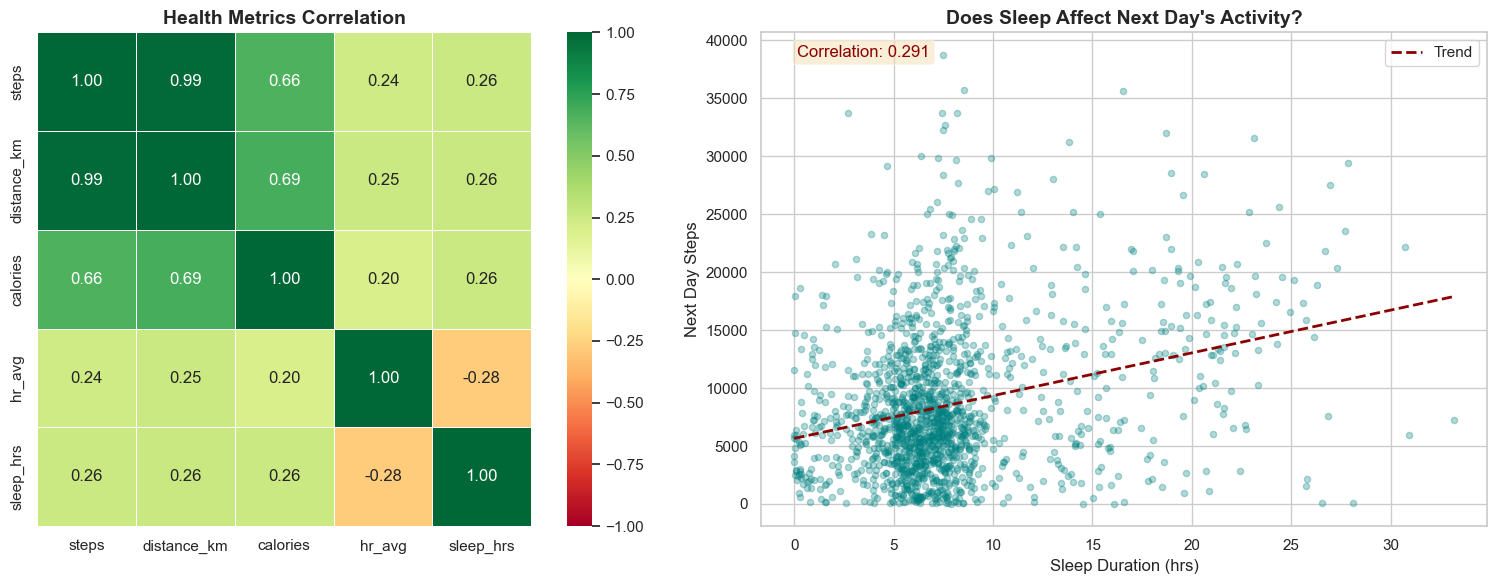

✅ Saved correlation_analysis.png


In [14]:
# correlation heatmap 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Correlation heatmap ────────────────────
corr_cols = ['steps', 'distance_km', 'calories', 'hr_avg', 'sleep_hrs']
corr_matrix = master[corr_cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            ax=axes[0],
            square=True,
            linewidths=0.5)
axes[0].set_title('Health Metrics Correlation', fontsize=14, fontweight='bold')

# ── Plot 2: Sleep vs Next-day Steps ───────────────
# Shift steps by 1 day to get "next day steps"
master_corr = master[['date', 'steps', 'sleep_hrs']].dropna().copy()
master_corr['next_day_steps'] = master_corr['steps'].shift(-1)
master_corr = master_corr.dropna()

axes[1].scatter(master_corr['sleep_hrs'], master_corr['next_day_steps'],
                alpha=0.3, color='teal', s=20)

# Trend line
valid = master_corr[['sleep_hrs', 'next_day_steps']].dropna()
z = np.polyfit(valid['sleep_hrs'], valid['next_day_steps'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['sleep_hrs'].min(), valid['sleep_hrs'].max(), 100)
axes[1].plot(x_line, p(x_line), color='darkred', linewidth=2,
             linestyle='--', label='Trend')
axes[1].set_title("Does Sleep Affect Next Day's Activity?", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sleep Duration (hrs)')
axes[1].set_ylabel('Next Day Steps')
axes[1].legend()

# Correlation value
corr_val = valid['sleep_hrs'].corr(valid['next_day_steps'])
axes[1].annotate(f'Correlation: {corr_val:.3f}', 
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=12, color='darkred',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../data/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved correlation_analysis.png")

✅ Anomaly detection complete!
   Total days analyzed: 466
   Anomalies detected:  24 days (5.2%)

🚨 Top 10 Most Anomalous Days:


,date,steps,hr_avg,sleep_hrs,anomaly_score
1882,2022-10-09,1155,142.80,6.91,-0.69
2133,2023-06-17,22085,64.41,30.91,-0.67
1905,2022-11-01,38761,98.38,9.41,-0.64
2232,2023-09-24,136,55.00,13.60,-0.63
1347,2021-04-22,6223,142.36,5.46,-0.63
1967,2023-01-02,938,64.49,26.82,-0.62
2074,2023-04-19,10606,50.77,17.03,-0.61
2053,2023-03-29,33743,99.51,13.80,-0.61
1881,2022-10-08,8949,133.92,2.28,-0.61
2218,2023-09-10,1351,54.80,10.14,-0.61


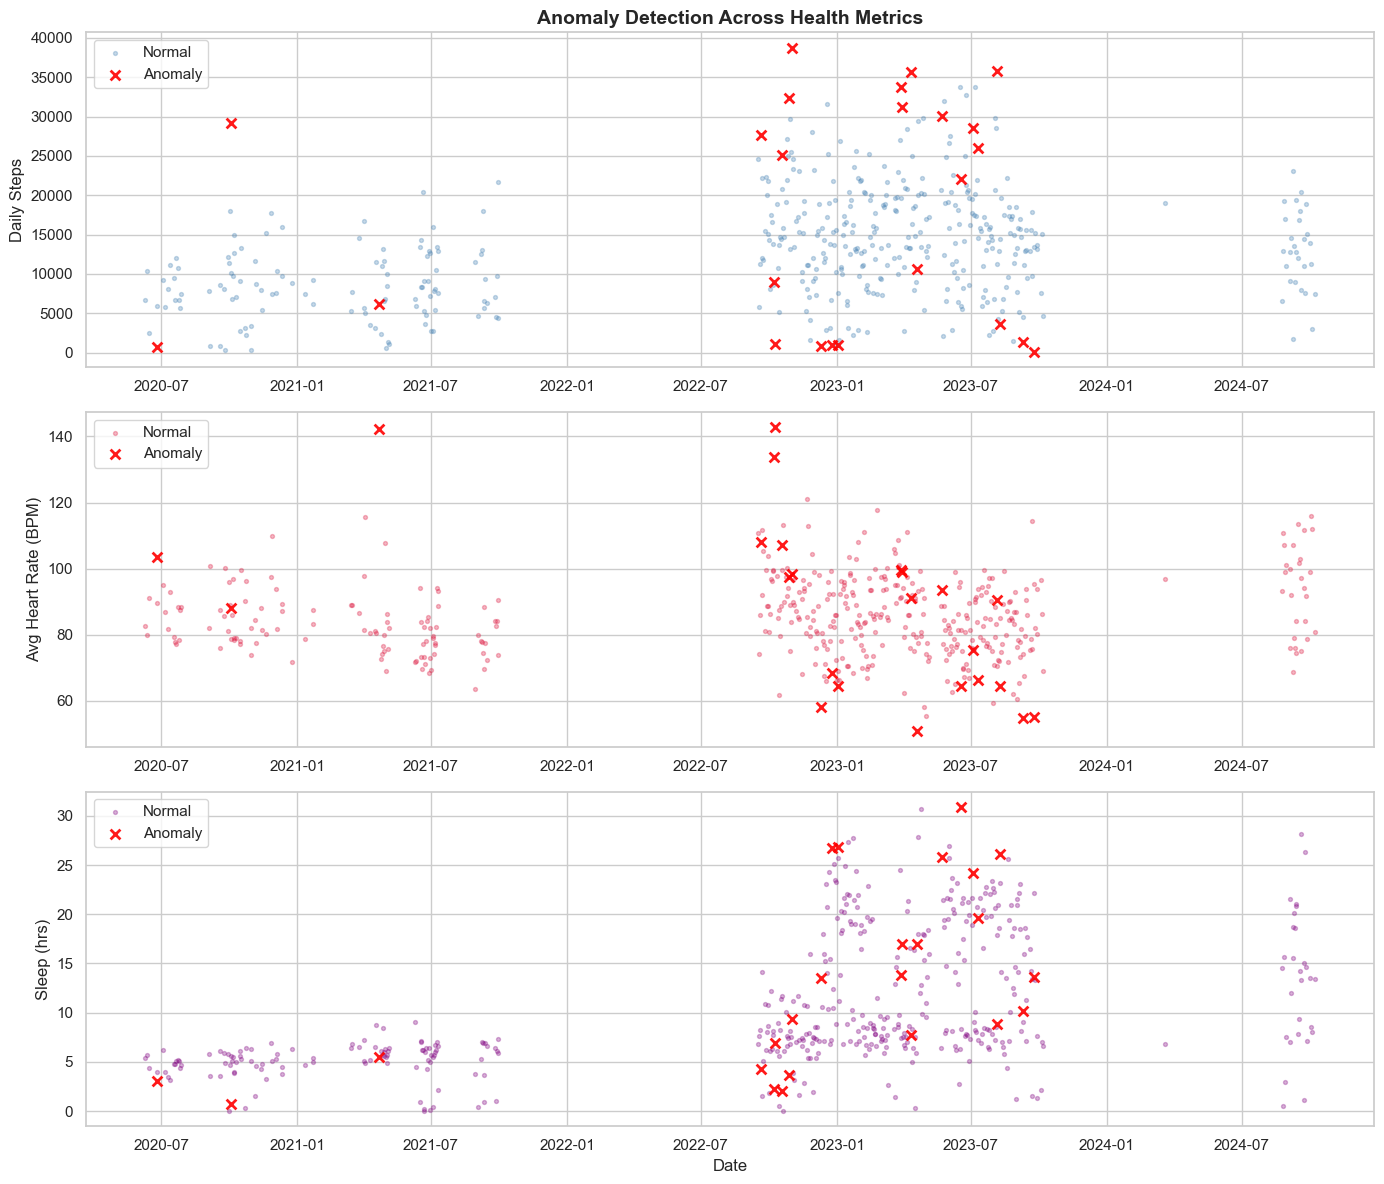

✅ Saved anomaly_detection.png


In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ── Prepare data ───────────────────────────────────
features = ['steps', 'hr_avg', 'sleep_hrs']
anomaly_df = master[features + ['date']].dropna().copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(anomaly_df[features])

# ── Fit Isolation Forest ───────────────────────────
iso_forest = IsolationForest(
    contamination=0.05,  # expect ~5% anomalies
    random_state=42,
    n_estimators=100
)
anomaly_df['anomaly'] = iso_forest.fit_predict(X_scaled)
anomaly_df['anomaly_score'] = iso_forest.score_samples(X_scaled)
anomaly_df['is_anomaly'] = anomaly_df['anomaly'] == -1

print(f"✅ Anomaly detection complete!")
print(f"   Total days analyzed: {len(anomaly_df):,}")
print(f"   Anomalies detected:  {anomaly_df['is_anomaly'].sum():,} days ({anomaly_df['is_anomaly'].mean()*100:.1f}%)")
print(f"\n🚨 Top 10 Most Anomalous Days:")
top_anomalies = anomaly_df[anomaly_df['is_anomaly']].nsmallest(10, 'anomaly_score')
display(top_anomalies[['date', 'steps', 'hr_avg', 'sleep_hrs', 'anomaly_score']].round(2))

# ── Visualize anomalies ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, metric, color, label in zip(
    axes,
    ['steps', 'hr_avg', 'sleep_hrs'],
    ['steelblue', 'crimson', 'purple'],
    ['Daily Steps', 'Avg Heart Rate (BPM)', 'Sleep (hrs)']
):
    # Normal days
    normal = anomaly_df[~anomaly_df['is_anomaly']]
    ax.scatter(normal['date'], normal[metric],
               alpha=0.3, s=8, color=color, label='Normal')
    
    # Anomaly days
    anom = anomaly_df[anomaly_df['is_anomaly']]
    ax.scatter(anom['date'], anom[metric],
               alpha=0.9, s=50, color='red', 
               marker='x', linewidths=2, label='Anomaly', zorder=5)
    
    ax.set_ylabel(label)
    ax.legend(loc='upper left')

axes[0].set_title('Anomaly Detection Across Health Metrics', 
                   fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../data/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved anomaly_detection.png")

In [17]:
# summary

# Save cleaned datasets for the dashboard
anomaly_df.to_csv('../data/anomaly_results.csv', index=False)

# Save yearly summary for dashboard
yearly_summary = master.groupby('year').agg(
    avg_steps=('steps', 'mean'),
    avg_sleep=('sleep_hrs', 'mean'),
    avg_hr=('hr_avg', 'mean'),
    avg_calories=('calories', 'mean'),
    days_10k=('steps', lambda x: (x >= 10000).sum()),
    total_days=('steps', 'count')
).reset_index()
yearly_summary['pct_10k'] = (yearly_summary['days_10k'] / yearly_summary['total_days'] * 100).round(1)
yearly_summary.to_csv('../data/yearly_summary.csv', index=False)

print("✅ Saved anomaly_results.csv")
print("✅ Saved yearly_summary.csv")
print("\n📊 Yearly Summary:")
display(yearly_summary.round(2))

✅ Saved anomaly_results.csv
✅ Saved yearly_summary.csv

📊 Yearly Summary:


,year,avg_steps,avg_sleep,avg_hr,avg_calories,days_10k,total_days,pct_10k
0,2017,4386.73,5.82,NaN,NaN,20,267,7.50
1,2018,5344.91,5.87,NaN,NaN,31,365,8.50
2,2019,3592.89,4.57,NaN,NaN,15,248,6.00
3,2020,5390.97,4.88,86.82,249.87,28,363,7.70
4,2021,5954.27,5.23,84.51,241.52,52,358,14.50
5,2022,9812.71,6.75,89.94,244.20,151,365,41.40
6,2023,12223.22,11.75,83.47,325.00,203,365,55.60
7,2024,6524.98,8.38,93.92,203.69,66,366,18.00
8,2025,5546.60,8.50,88.44,271.01,40,365,11.00
9,2026,4420.59,NaN,NaN,NaN,5,64,7.80


In [23]:
# ai agent 

import anthropic
import os
from dotenv import load_dotenv

# Load key from .env file
load_dotenv('/Users/victoria/Desktop/DE/DS/Project/apple_health_export/apple_health_analysis/.env')

client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=100,
    messages=[{"role": "user", "content": "Say hello!"}]
)
print(response.content[0].text)

AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011CYkhWWPHwCW2x7Mt4Jwht'}

In [24]:
from dotenv import load_dotenv
import os

load_dotenv('/Users/victoria/Desktop/DE/DS/Project/apple_health_export/apple_health_analysis/.env')
print(repr(os.getenv("ANTHROPIC_API_KEY")))

'sk-ant-api03-yournewkey...'


In [27]:
from dotenv import load_dotenv
import os

load_dotenv('/Users/victoria/Desktop/DE/DS/Project/apple_health_export/apple_health_analysis/.env', override=True)

key = os.getenv("ANTHROPIC_API_KEY")
print(f"Key length: {len(key) if key else 0}")

Key length: 108


In [28]:
import anthropic
from dotenv import load_dotenv
import os

load_dotenv('/Users/victoria/Desktop/DE/DS/Project/apple_health_export/apple_health_analysis/.env', override=True)

client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=100,
    messages=[{"role": "user", "content": "Say hello!"}]
)
print(response.content[0].text)

Hello! It's nice to meet you. How are you doing today?
